In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


class StockPredictionModel:

    def __init__(self, ticker, period='5y'):
        self.ticker = ticker
        self.period = period
        self.model = RandomForestRegressor(n_estimators=100, random_state=42)

        # features used for training
        self.features = ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'SMA_21']

        self.df = None


    def fetch_and_preprocess(self):

        df = yf.download(self.ticker, period=self.period, interval='1d', auto_adjust=True)

        # Fix multiindex column issue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [col[0] for col in df.columns]

        # Moving averages
        df['SMA_7'] = df['Close'].rolling(7).mean()
        df['SMA_21'] = df['Close'].rolling(21).mean()

        # Target = next day close price
        df['Target'] = df['Close'].shift(-1)

        df = df.dropna()

        self.df = df

        return df


    def train_and_evaluate(self):

        X = self.df[self.features]
        y = self.df['Target']

        split = int(len(X) * 0.8)

        X_train = X[:split]
        X_test = X[split:]

        y_train = y[:split]
        y_test = y[split:]

        # Train model
        self.model.fit(X_train, y_train)

        # Predict
        y_pred = self.model.predict(X_test)

        # Metrics
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"\nResults for {self.ticker}")
        print("MSE:", round(mse,4))
        print("R2 Score:", round(r2,4))

        # Save trained model
        joblib.dump(self.model, "aapl_stock_model.pkl")

        print("\nModel saved as aapl_stock_model.pkl")

        return X_test, y_test, y_pred


    def predict_next_day(self):

        # Load saved model
        model = joblib.load("aapl_stock_model.pkl")

        latest = self.df[self.features].tail(1)

        prediction = model.predict(latest)[0]

        print(f"\nPredicted next day price for {self.ticker}: {prediction:.2f}")

        return prediction


# ---------------- RUN MODEL ---------------- #

model_instance = StockPredictionModel("AAPL")

model_instance.fetch_and_preprocess()

xtest, ytest, ypred = model_instance.train_and_evaluate()

# Predict tomorrow
model_instance.predict_next_day()

[*********************100%***********************]  1 of 1 completed



Results for AAPL
MSE: 128.9072
R2 Score: 0.8501

Model saved as aapl_stock_model.pkl

Predicted next day price for AAPL: 253.48


np.float64(253.4818051147461)

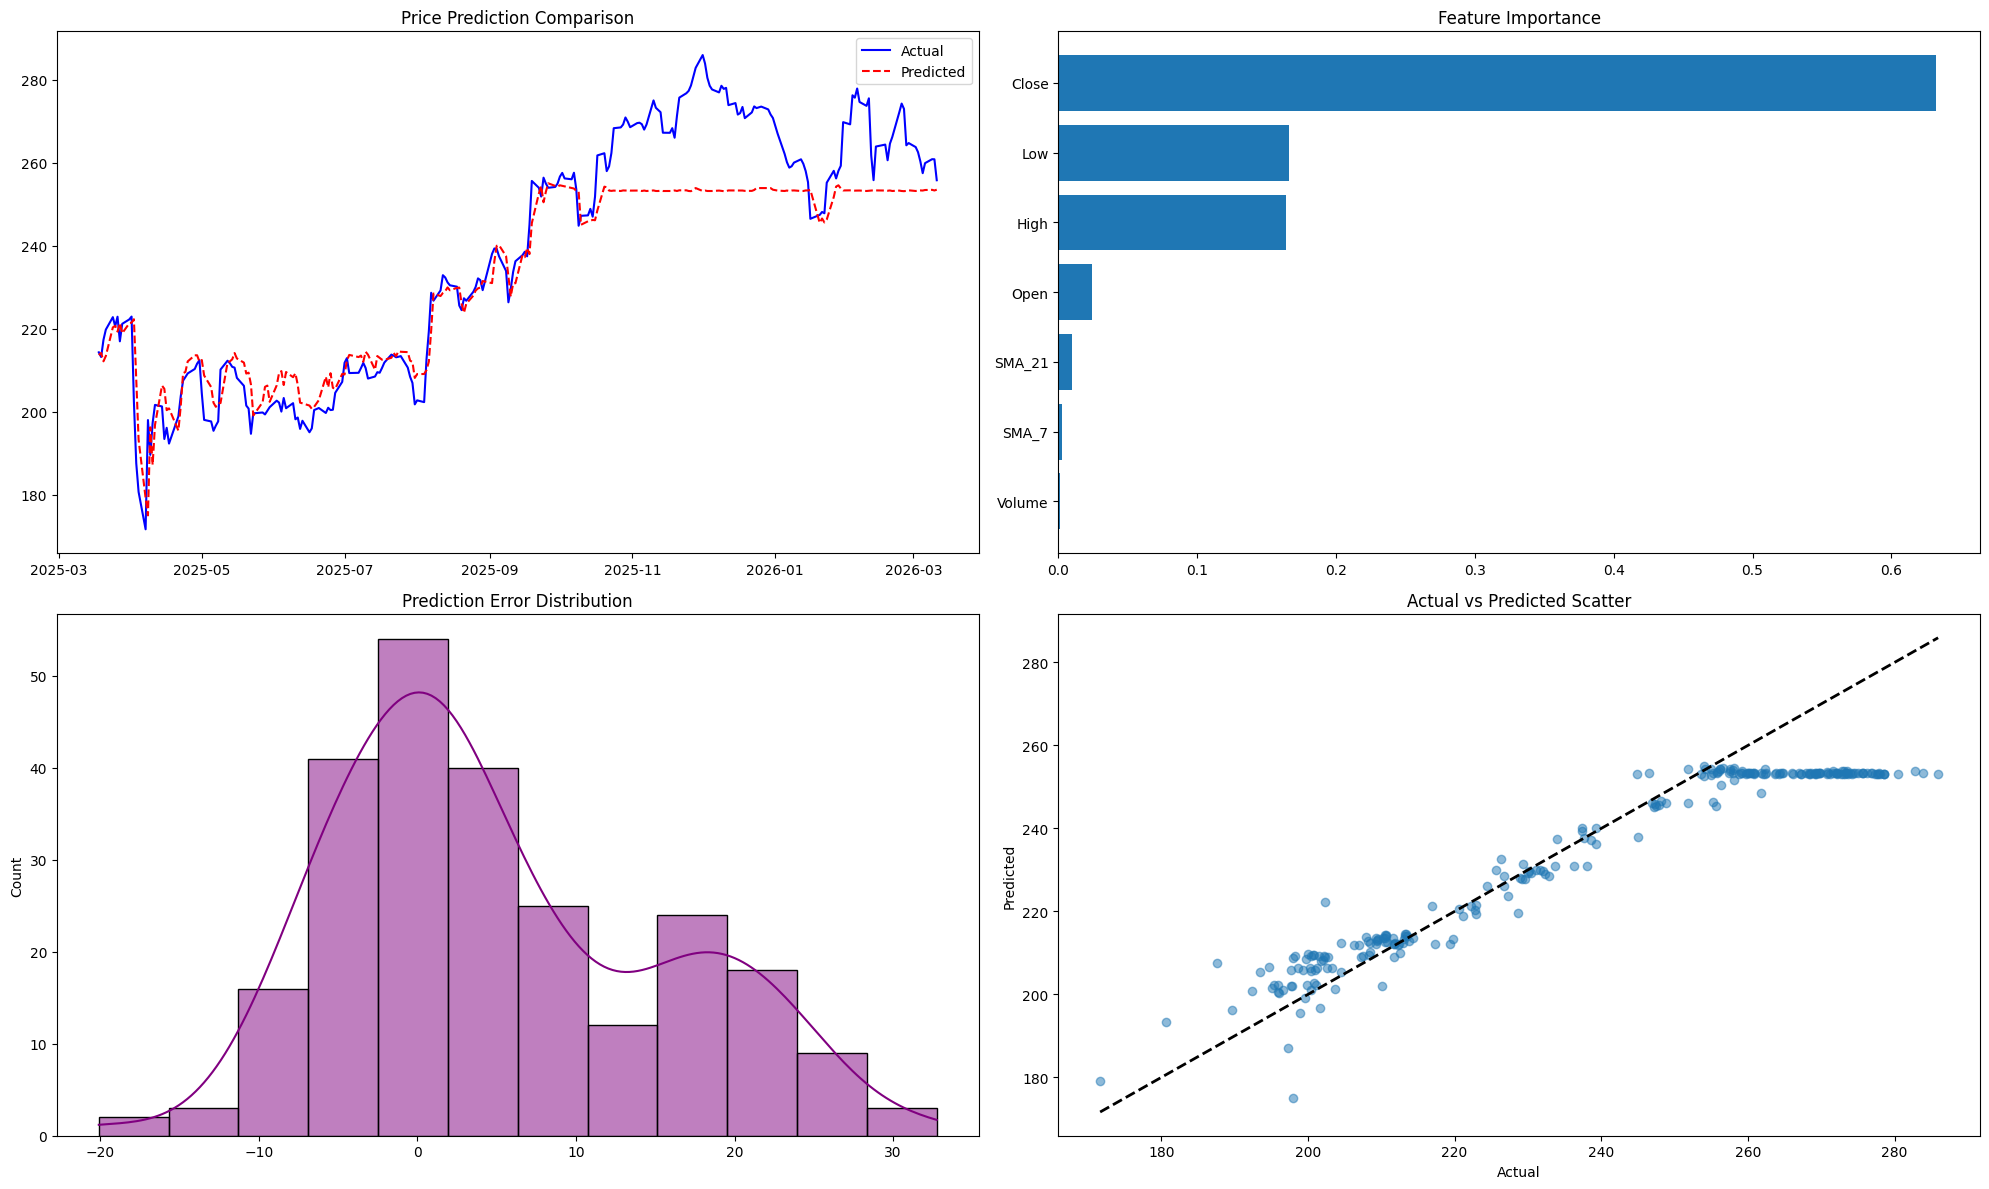

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

axes[0, 0].plot(ytest.index, ytest.values, label='Actual', color='blue')
axes[0, 0].plot(ytest.index, ypred, label='Predicted', color='red', linestyle='--')
axes[0, 0].set_title('Price Prediction Comparison')
axes[0, 0].legend()

importances = model_instance.model.feature_importances_
indices = np.argsort(importances)
axes[0, 1].barh(range(len(indices)), importances[indices], align='center')
axes[0, 1].set_yticks(range(len(indices)), [model_instance.features[i] for i in indices])
axes[0, 1].set_title('Feature Importance')

errors = ytest.values - ypred
sns.histplot(errors, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Prediction Error Distribution')

axes[1, 1].scatter(ytest.values, ypred, alpha=0.5)
axes[1, 1].plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'k--', lw=2)
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title('Actual vs Predicted Scatter')

plt.tight_layout()
plt.show()

In [16]:
import pickle
from google.colab import files

with open('aapl_stock_model.pkl', 'wb') as f:
    pickle.dump(model_instance.model, f)

files.download('aapl_stock_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>